# Support Vector Regression

I use one small example to understand the epsilon tube, then apply an RBF SVR to one California housing feature.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## 1. Linear SVR

Errors inside the epsilon tube are ignored. A larger `C` penalizes points outside the tube more strongly and can make the model fit the training data too closely.


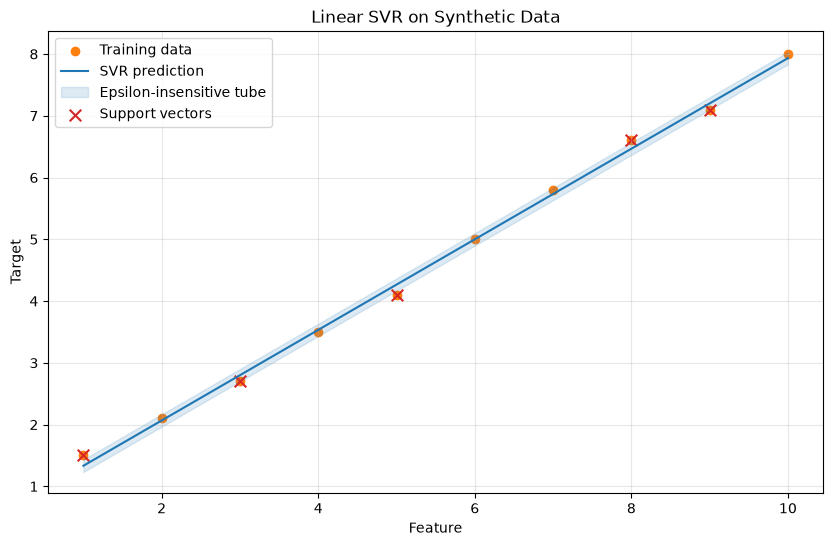

In [2]:
X = np.arange(1, 11, dtype=float).reshape(-1, 1)
y = np.array([1.5, 2.1, 2.7, 3.5, 4.1, 5.0, 5.8, 6.6, 7.1, 8.0])

epsilon = 0.1
# A linear kernel keeps the epsilon tube easy to visualize.
svr = SVR(kernel="linear", C=100, epsilon=epsilon)
svr.fit(X, y)
y_pred = svr.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, color="tab:orange", label="Training data")
plt.plot(X[:, 0], y_pred, color="tab:blue", label="SVR prediction")
plt.fill_between(
    X[:, 0],
    y_pred - epsilon,
    y_pred + epsilon,
    color="tab:blue",
    alpha=0.15,
    label="Epsilon-insensitive tube",
)
plt.scatter(
    X[svr.support_, 0],
    y[svr.support_],
    color="tab:red",
    marker="x",
    s=70,
    label="Support vectors",
)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear SVR on Synthetic Data")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 2. California housing

I use median income so the fitted curve can be shown in two dimensions. The model uses a limited sample to keep kernel SVR practical, and the final metrics stay in the original house-value units.


Test MAE: 0.610
Test R^2: 0.467


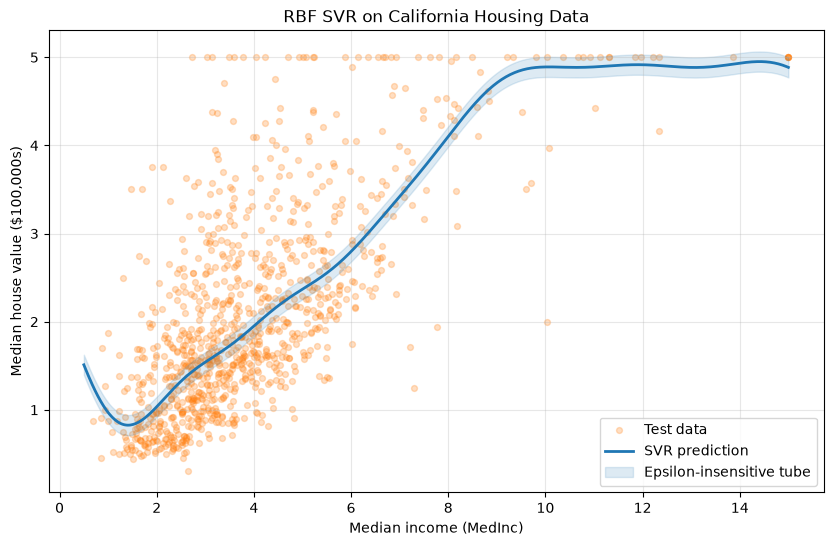

In [3]:
housing = fetch_california_housing()
X = housing.data[:, [0]]  # MedInc: median income in each district
y = housing.target

# Use a smaller random sample because kernel SVR scales poorly.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=4000,
    test_size=1000,
    random_state=42,
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

housing_epsilon = 0.1
housing_svr = SVR(kernel="rbf", C=10, epsilon=housing_epsilon, gamma="scale")
housing_svr.fit(X_train_scaled, y_train_scaled)

y_test_pred_scaled = housing_svr.predict(X_test_scaled)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"Test R^2: {r2_score(y_test, y_test_pred):.3f}")

x_grid = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_grid_scaled = housing_svr.predict(x_scaler.transform(x_grid))
y_grid = y_scaler.inverse_transform(y_grid_scaled.reshape(-1, 1)).ravel()
# Convert epsilon from standardized targets back to house-value units.
epsilon_original = housing_epsilon * y_scaler.scale_[0]

plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, alpha=0.25, s=18, color="tab:orange", label="Test data")
plt.plot(x_grid[:, 0], y_grid, color="tab:blue", linewidth=2, label="SVR prediction")
plt.fill_between(
    x_grid[:, 0],
    y_grid - epsilon_original,
    y_grid + epsilon_original,
    color="tab:blue",
    alpha=0.15,
    label="Epsilon-insensitive tube",
)
plt.xlabel("Median income (MedInc)")
plt.ylabel("Median house value ($100,000s)")
plt.title("RBF SVR on California Housing Data")
plt.grid(alpha=0.3)
plt.legend()
plt.show()